In [23]:
import json
import base64
from pathlib import Path

import fitz  # PyMuPDF
import requests
from openai import OpenAI
from PIL import Image
from IPython.display import display


DOCLING_URL = "http://localhost:5001/v1/convert/file"

GRANITE_URL = "http://localhost:11434/v1"  # Ollama
GRANITE_API_KEY = "ollama"
GRANITE_MODEL = "ibm/granite-docling:258m"

PDF_PATH = "./data/LE_sample.pdf"

PAGE_IMAGE_DIR = Path("page_images")
PAGE_IMAGE_DIR.mkdir(exist_ok=True)

## Step 1 - Docling Standard Pipeline OCR, Tables,

In [24]:
def run_docling(pdf_path):
    with open(pdf_path, "rb") as f:
        r = requests.post(
            DOCLING_URL,
            files={"files": f},
            data={
                "pipeline": "standard", # includes Layout parser
                "ocr": "true",
                "tables": "true",
                "to_formats": ["md", "json"]
            },
            timeout=600
        )

    r.raise_for_status()
    return r.json()


docling_result = run_docling(PDF_PATH)

# Debug: inspect top-level keys and structure
print("Top-level keys:", list(docling_result.keys()))
doc = docling_result.get("document") or {}
print("Document keys:", list(doc.keys()) if doc else "No 'document' key found")
print("md_content preview:", str(doc.get("md_content", ""))[:300] or "(empty)")


Top-level keys: ['document', 'status', 'errors', 'processing_time', 'timings']
Document keys: ['filename', 'md_content', 'json_content', 'html_content', 'text_content', 'doctags_content']
md_content preview: ## TILA RESPA Integrated Disclosure

## H-24(B) Mortgage Loan Transaction Loan Estimate - Fixed Rate Loan Sample

This is a sample of a completed Loan Estimate for a fixed rate loan.  This loan is for the purchase of property at a sale price of $180,000 and has a loan amount of $162,000, a 30-year l


In [25]:
def extract_pages(docling_result):
    doc = docling_result.get("document") or {}

    # json_content can be a dict or a JSON string depending on upstream config
    doc_json = doc.get("json_content") or {}
    if isinstance(doc_json, str):
        try:
            doc_json = json.loads(doc_json)
        except json.JSONDecodeError:
            doc_json = {}

    pages_raw = doc_json.get("pages", []) if isinstance(doc_json, dict) else []

    # Fall back to full markdown as a single page
    markdown = doc.get("md_content") or ""

    page_items = []

    if pages_raw:
        for i, p in enumerate(pages_raw, 1):
            if isinstance(p, dict):
                text = p.get("text") or p.get("content") or ""
                page_number = p.get("page") or p.get("page_no") or i
            elif isinstance(p, str):
                text = p
                page_number = i
            else:
                text = str(p)
                page_number = i

            page_items.append({
                "page_number": page_number,
                "text": text
            })
    elif markdown:
        page_items.append({
            "page_number": 1,
            "text": markdown
        })
    else:
        print("Warning: no text content found in Docling response.")

    return page_items


def render_pages(pdf_path):
    doc = fitz.open(pdf_path)
    page_map = {}

    for i in range(len(doc)):
        page = doc[i]
        pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
        path = PAGE_IMAGE_DIR / f"page_{i+1}.png"
        pix.save(path)
        page_map[i+1] = str(path)

    return page_map


pages = extract_pages(docling_result)
page_images = render_pages(PDF_PATH)

print(f"Pages extracted: {len(pages)}")
if pages:
    print("First page text preview:", str(pages[0]["text"])[:300])

Pages extracted: 4
First page text preview: 1


## Step 3 - Output of Docling OCR, Layout, Table + Prompt  to Docling Granite 

In [26]:
import re

client = OpenAI(
    base_url=GRANITE_URL,
    api_key=GRANITE_API_KEY
)


def image_to_data_url(path):
    with open(path, "rb") as f:
        return "data:image/png;base64," + base64.b64encode(f.read()).decode()


def needs_granite(text):
    t = text.lower()
    # Use word boundaries for common words to avoid false positives
    triggers = ["checkbox", "☑", "☐", "signature"]
    word_triggers = [r"\byes\b", r"\bno\b"]
    return (
        any(t_str in t for t_str in triggers)
        or any(re.search(pat, t) for pat in word_triggers)
    )


def run_granite(page_number, text, image_path):
    prompt = f"""
Extract structured information from this document page using both text and image.

Return ONLY valid JSON in this generic format:
{{
  "page": {page_number},
  "summary": "",
  "entities": [{{"type": "", "value": "", "confidence": 0.0}}],
  "key_values": [{{"key": "", "value": "", "confidence": 0.0}}],
  "tables": [{{"title": "", "rows": []}}],
  "actions": [""],
  "notes": []
}}

Rules:
- Do not add markdown or explanations.
- If a section is not present, return an empty list/string.
- Keep the JSON parseable.

Text:
{text}
"""

    res = client.chat.completions.create(
        model=GRANITE_MODEL,
        temperature=0,
        max_tokens=2000,
        messages=[
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": image_to_data_url(image_path)}
                    }
                ]
            }
        ]
    )

    raw = res.choices[0].message.content

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return {"error": raw}


Trigger-matched pages: 0 / 4
No pages matched heuristic; falling back to first 2 pages.

--- Page 1 ---
Text preview: 1


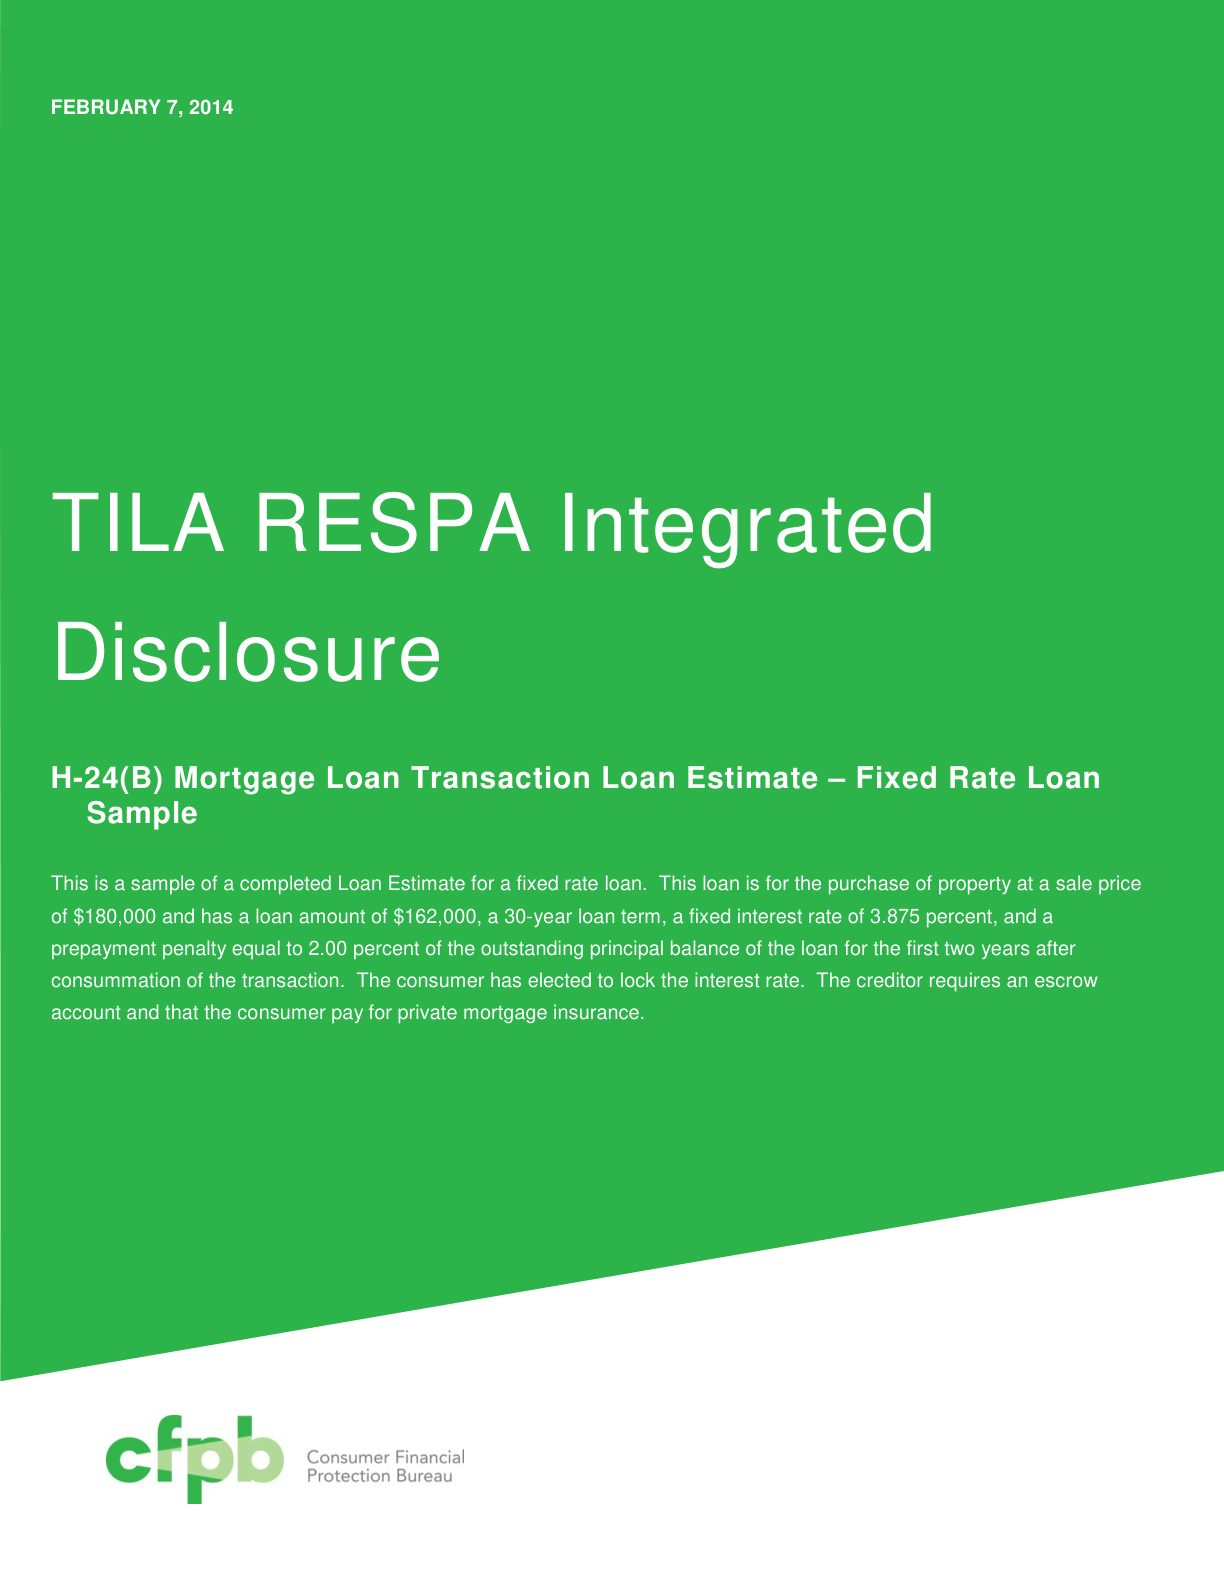

{
  "error": "<doctag><section_header_level_1><loc_21><loc_153><loc_387><loc_221>TILA RESPA Integrated Disclosure</section_header_level_1>\n<text><loc_20><loc_243><loc_450><loc_263>H-24(B) Mortgage Loan Transaction Loan Estimate \u2013 Fixed Rate Loan Sample</text>\n<text><loc_20><loc_277><loc_467><loc_324>This is a sample of a completed Loan Estimate for a fixed rate loan. This loan is for the purchase of property at a sale price of $180,000 and has a loan amount of $162,000, a 30-year loan term, a fixed interest rate of 3.875 percent, and a prepayment penalty equal to 2.00 percent of the outstanding principal balance of the loan for the first two years after consummation of the transaction. The consumer has elected to lock the interest rate. The creditor requires an escrow account and that the consumer pay for private mortgage insurance.</text>\n<picture><loc_43><loc_447><loc_191><loc_476></picture>\n</doctag>"
}

--- Page 2 ---
Text preview: 2


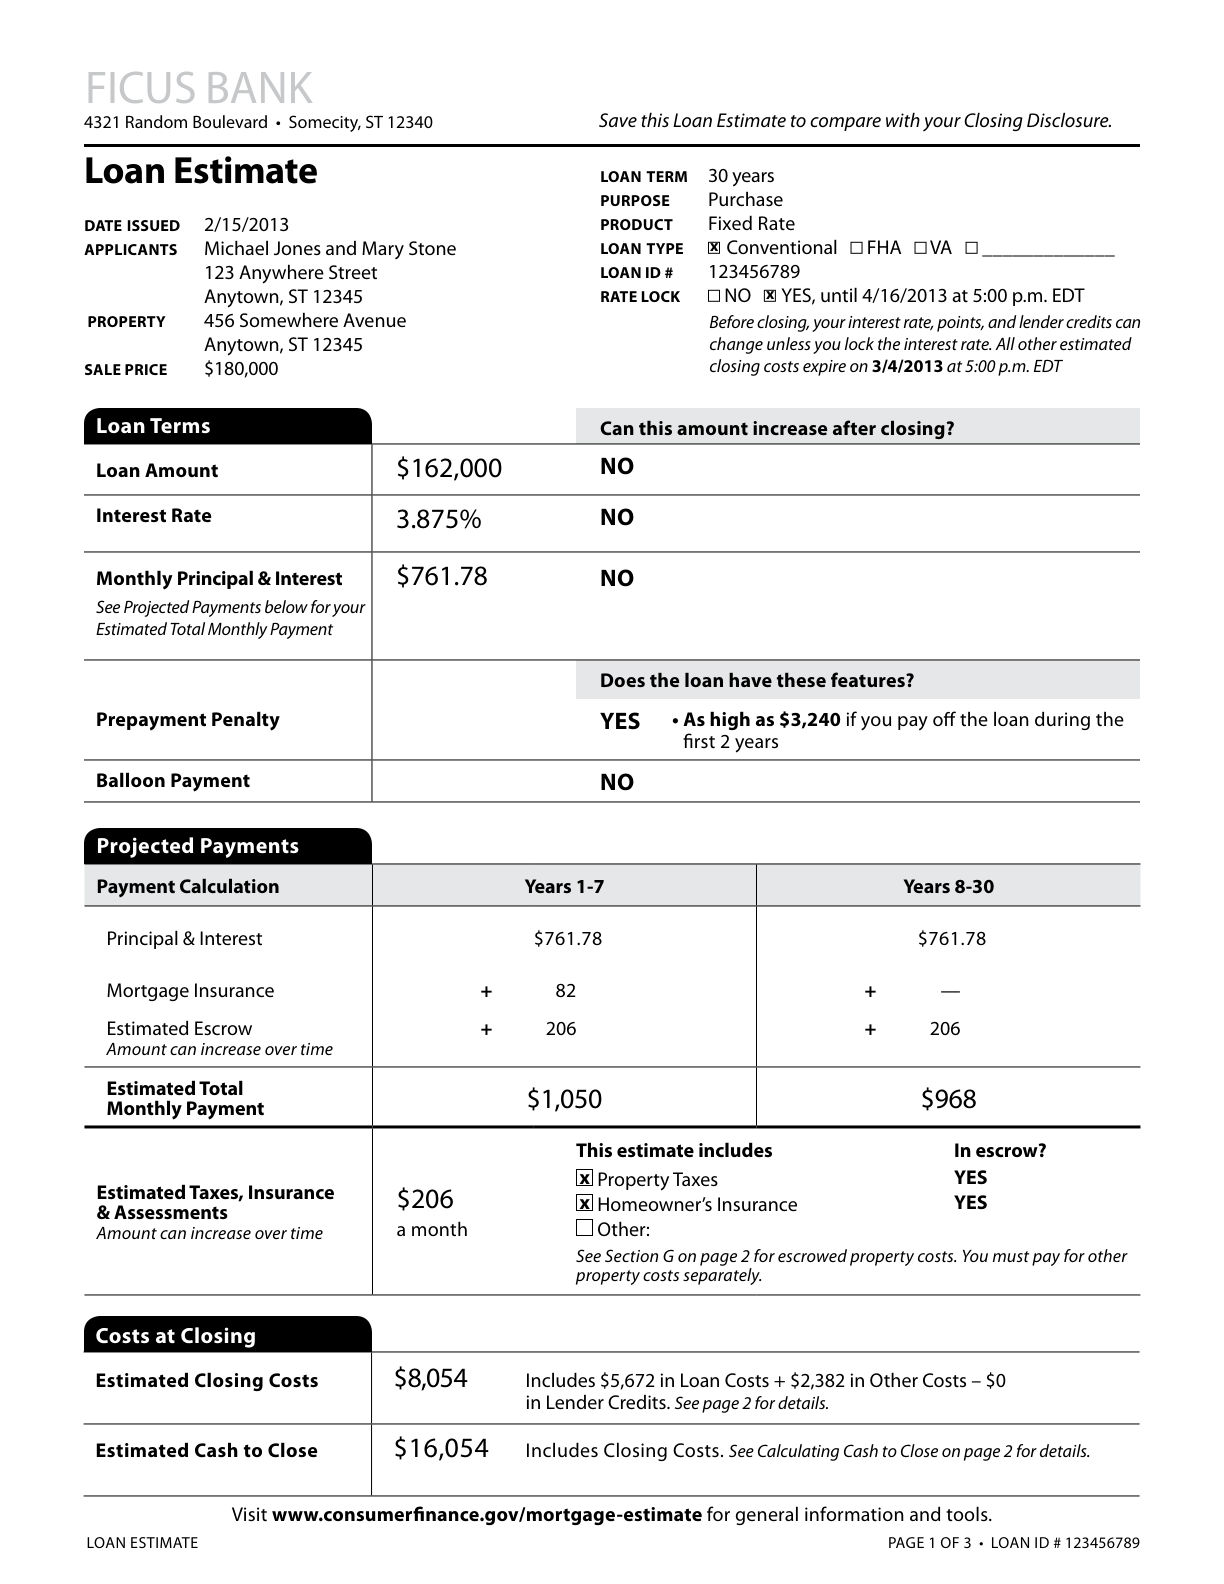

{
  "error": "<doctag><section_header_level_1><loc_35><loc_23><loc_128><loc_36>FICUS BANK</section_header_level_1>\n<text><loc_34><loc_38><loc_178><loc_43>4321 Random Boulevard \u00b7 Somecity, ST 12340</text>\n<section_header_level_1><loc_35><loc_50><loc_130><loc_61>Loan Estimate</section_header_level_1>\n<otsl><loc_33><loc_63><loc_464><loc_467><fcel>DATE ISSUED<fcel>2/15/2013 Michael Jones and Mary Stone 123 Anywhere Street  Anytown, ST 12345 456 Somewhere Avenue  Anytown, ST 12345 $180,000<ecel><nl><fcel>PROPERTY SALE PRICE<fcel>$162,000 NO<ecel><nl><fcel>Loan Terms<ecel><ecel><nl><fcel>Interest Rate<fcel>3.875% NO<ecel><nl><fcel>Monthly Principal & Interest See Projected Payments below for your Estimated Total Monthly Payment<fcel>$761.78 NOI<ecel><nl><ecel><ecel><fcel>Does the loan have these features? YES \u00b7 As high as $3,240 if you pay off the loan during the first 2 years<nl><fcel>Prepayment Penalty Balloon Payment<ecel><ecel><nl><ecel><ecel><fcel>NO<nl><fcel>Projected Paym

In [27]:
results = []

# Identify pages that match the trigger heuristic
matched_pages = [p for p in pages if needs_granite(str(p.get("text", "")))]
print(f"Trigger-matched pages: {len(matched_pages)} / {len(pages)}")

# Fallback: if nothing matched, process first 2 pages so you still get output
if matched_pages:
    pages_to_process = matched_pages
else:
    pages_to_process = pages[:2]
    print("No pages matched heuristic; falling back to first 2 pages.")

for p in pages_to_process:
    page_number = int(p.get("page_number", 1))
    text = str(p.get("text", ""))

    img_path = page_images.get(page_number)
    if not img_path:
        print(f"Skipping page {page_number}: image not found")
        continue

    print(f"\n--- Page {page_number} ---")
    print("Text preview:", text[:200].replace("\n", " "))
    display(Image.open(img_path))

    result = run_granite(page_number, text, img_path)
    results.append(result)
    print(json.dumps(result, indent=2))

print(f"\nTotal results collected: {len(results)}")